# Region Topic Analysis

This tutorial covers topic modeling analysis with TF-MInDi:
- Running topic modeling on regions using {func}`~tfmindi.tl.run_topic_modeling`
- Evaluating different topic numbers with {func}`~tfmindi.tl.evaluate_topic_models`
- Analyzing topic-cluster and topic-DBD relationships
- Visualizing topics in t-SNE space and heatmaps

In [1]:
import tfmindi as tm

DATA_DIR = "../../../../data/tfmindi/"

# Clustering resolution used in the previous tutorial; it names the annotation column.
res = 5.0
ANNOTATION_COL = f"predicted_{res}_predicted_family"

In [2]:
# Load clustered data from previous tutorial
adata = tm.load_h5ad(DATA_DIR + "seqlets_clustered.h5ad")

## Running Topic Modeling

Topic modeling helps discover co-occurring TF binding patterns across genomic regions. We use {func}`~tfmindi.tl.run_topic_modeling` which applies Latent Dirichlet Allocation (LDA) to find topics based on seqlet cluster compositions.

Each region gets a topic probability distribution, and each topic represents a pattern of co-occurring TF binding clusters.

The results of the topic modeling will be stored in our `anndata.uns["topic_modeling"]`.

In [3]:
# Run topic modeling with 15 topics
tm.tl.run_topic_modeling(adata, annotation_col=ANNOTATION_COL, n_topics=15, random_state=42)

Filtered 0 seqlets with unknown DBD annotations
Using 679653 deduplicated seqlets across 37265 regions


2025-09-09 14:51:29 | [INFO] n_documents: 37265
2025-09-09 14:51:29 | [INFO] vocab_size: 63
2025-09-09 14:51:29 | [INFO] n_words: 679653
2025-09-09 14:51:29 | [INFO] n_topics: 15
2025-09-09 14:51:29 | [INFO] n_iter: 150


Count matrix shape: (37265, 63) (regions × clusters)
Fitting LDA model with 15 topics...


2025-09-09 14:51:29 | [INFO] <0> log likelihood: -4605356
2025-09-09 14:51:30 | [INFO] <10> log likelihood: -4494132
2025-09-09 14:51:31 | [INFO] <20> log likelihood: -4246345
2025-09-09 14:51:31 | [INFO] <30> log likelihood: -3831663
2025-09-09 14:51:32 | [INFO] <40> log likelihood: -3576805
2025-09-09 14:51:33 | [INFO] <50> log likelihood: -3389256
2025-09-09 14:51:33 | [INFO] <60> log likelihood: -3245509
2025-09-09 14:51:34 | [INFO] <70> log likelihood: -3156747
2025-09-09 14:51:35 | [INFO] <80> log likelihood: -3110035
2025-09-09 14:51:35 | [INFO] <90> log likelihood: -3083700
2025-09-09 14:51:36 | [INFO] <100> log likelihood: -3059641
2025-09-09 14:51:37 | [INFO] <110> log likelihood: -3041184
2025-09-09 14:51:37 | [INFO] <120> log likelihood: -3020762
2025-09-09 14:51:38 | [INFO] <130> log likelihood: -3008703
2025-09-09 14:51:39 | [INFO] <140> log likelihood: -3001027
2025-09-09 14:51:39 | [INFO] <149> log likelihood: -2994522


Stored topic modeling results in adata.uns['topic_modeling']


## Evaluating Topic Numbers

To find the optimal number of topics, use {func}`~tfmindi.tl.evaluate_topic_models`. This tests different topic numbers and provides log likelihood scores to help choose the best model.  
The best topic model will again be stored in the `anndata.uns` (will overwrite any existing models).  

In [4]:
# Evaluate topic models with different numbers of topics
topic_range = [5, 20, 30, 50, 80, 100]
results = tm.tl.evaluate_topic_models(adata, topic_range, annotation_col=ANNOTATION_COL, random_state=42)

Evaluating 6 different topic models...
Training model with 5 topics...
Filtered 0 seqlets with unknown DBD annotations
Using 679653 deduplicated seqlets across 37265 regions


2025-09-09 14:54:10 | [INFO] n_documents: 37265
2025-09-09 14:54:10 | [INFO] vocab_size: 63
2025-09-09 14:54:10 | [INFO] n_words: 679653
2025-09-09 14:54:10 | [INFO] n_topics: 5
2025-09-09 14:54:10 | [INFO] n_iter: 150


Count matrix shape: (37265, 63) (regions × clusters)
Fitting LDA model with 5 topics...


2025-09-09 14:54:10 | [INFO] <0> log likelihood: -3807192
2025-09-09 14:54:11 | [INFO] <10> log likelihood: -3774127
2025-09-09 14:54:11 | [INFO] <20> log likelihood: -3713713
2025-09-09 14:54:11 | [INFO] <30> log likelihood: -3465458
2025-09-09 14:54:12 | [INFO] <40> log likelihood: -3251093
2025-09-09 14:54:12 | [INFO] <50> log likelihood: -3127171
2025-09-09 14:54:12 | [INFO] <60> log likelihood: -3032957
2025-09-09 14:54:13 | [INFO] <70> log likelihood: -2961105
2025-09-09 14:54:13 | [INFO] <80> log likelihood: -2912052
2025-09-09 14:54:13 | [INFO] <90> log likelihood: -2881054
2025-09-09 14:54:14 | [INFO] <100> log likelihood: -2860732
2025-09-09 14:54:14 | [INFO] <110> log likelihood: -2843282
2025-09-09 14:54:14 | [INFO] <120> log likelihood: -2835591
2025-09-09 14:54:15 | [INFO] <130> log likelihood: -2827376
2025-09-09 14:54:15 | [INFO] <140> log likelihood: -2824307
2025-09-09 14:54:15 | [INFO] <149> log likelihood: -2819196


Stored topic modeling results in adata.uns['topic_modeling']
Model with 5 topics: log-likelihood = 1581135.96
Training model with 20 topics...
Filtered 0 seqlets with unknown DBD annotations
Using 679653 deduplicated seqlets across 37265 regions


...

Stored topic modeling results in adata.uns['topic_modeling']
Model with 100 topics: log-likelihood = 3225860.75
Storing best model with 30 topics...
Filtered 0 seqlets with unknown DBD annotations
Using 679653 deduplicated seqlets across 37265 regions


2025-09-09 14:56:54 | [INFO] n_documents: 37265
2025-09-09 14:56:54 | [INFO] vocab_size: 63
2025-09-09 14:56:54 | [INFO] n_words: 679653
2025-09-09 14:56:54 | [INFO] n_topics: 30
2025-09-09 14:56:54 | [INFO] n_iter: 150


Count matrix shape: (37265, 63) (regions × clusters)
Fitting LDA model with 30 topics...


2025-09-09 14:56:54 | [INFO] <0> log likelihood: -5124240
2025-09-09 14:56:55 | [INFO] <10> log likelihood: -4926744
2025-09-09 14:56:56 | [INFO] <20> log likelihood: -4500532
2025-09-09 14:56:57 | [INFO] <30> log likelihood: -4111923
2025-09-09 14:56:59 | [INFO] <40> log likelihood: -3818461
2025-09-09 14:57:00 | [INFO] <50> log likelihood: -3619094
2025-09-09 14:57:01 | [INFO] <60> log likelihood: -3494396
2025-09-09 14:57:02 | [INFO] <70> log likelihood: -3408447
2025-09-09 14:57:03 | [INFO] <80> log likelihood: -3347527
2025-09-09 14:57:04 | [INFO] <90> log likelihood: -3311364
2025-09-09 14:57:05 | [INFO] <100> log likelihood: -3282642
2025-09-09 14:57:06 | [INFO] <110> log likelihood: -3264805
2025-09-09 14:57:07 | [INFO] <120> log likelihood: -3252164
2025-09-09 14:57:09 | [INFO] <130> log likelihood: -3236494
2025-09-09 14:57:10 | [INFO] <140> log likelihood: -3226823
2025-09-09 14:57:11 | [INFO] <149> log likelihood: -3221774


Stored topic modeling results in adata.uns['topic_modeling']


In [5]:
# find n topics with highest log likelihood
best_n = max(results, key=results.get)
print(f"Best number of topics: {best_n} with log likelihood {results[best_n]}")

Best number of topics: 30 with log likelihood 5343808.110845597


## Topic-Cluster Analysis

Our topic modeling results include probabilities for which region belong to which topic.  

In [11]:
adata.uns["topic_modeling"]["region_topic_matrix"].head()

,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9,Topic_10,...,Topic_21,Topic_22,Topic_23,Topic_24,Topic_25,Topic_26,Topic_27,Topic_28,Topic_29,Topic_30
0,0.023148,0.023148,0.023148,0.078704,0.023148,0.023148,0.023148,0.037037,0.023148,0.023148,...,0.023148,0.023148,0.023148,0.037037,0.037037,0.023148,0.092593,0.023148,0.023148,0.037037
1,0.021930,0.035088,0.021930,0.021930,0.035088,0.021930,0.035088,0.021930,0.021930,0.021930,...,0.021930,0.087719,0.021930,0.048246,0.074561,0.035088,0.035088,0.021930,0.021930,0.021930
2,0.026882,0.026882,0.043011,0.091398,0.026882,0.026882,0.026882,0.026882,0.026882,0.043011,...,0.026882,0.026882,0.026882,0.059140,0.026882,0.026882,0.043011,0.026882,0.026882,0.026882
3,0.018519,0.018519,0.018519,0.096296,0.029630,0.018519,0.018519,0.074074,0.018519,0.029630,...,0.018519,0.018519,0.018519,0.051852,0.074074,0.040741,0.107407,0.018519,0.018519,0.018519
4,0.023810,0.038095,0.038095,0.023810,0.038095,0.023810,0.023810,0.066667,0.023810,0.038095,...,0.023810,0.066667,0.023810,0.023810,0.023810,0.038095,0.066667,0.038095,0.023810,0.023810


## Visualizing Topics

### DBD-Topic Heatmap

Visualize the relationship between topics and DNA-binding domains using {func}`~tfmindi.pl.dbd_topic_heatmap`.
This shows us which DBDs often co-occur.  

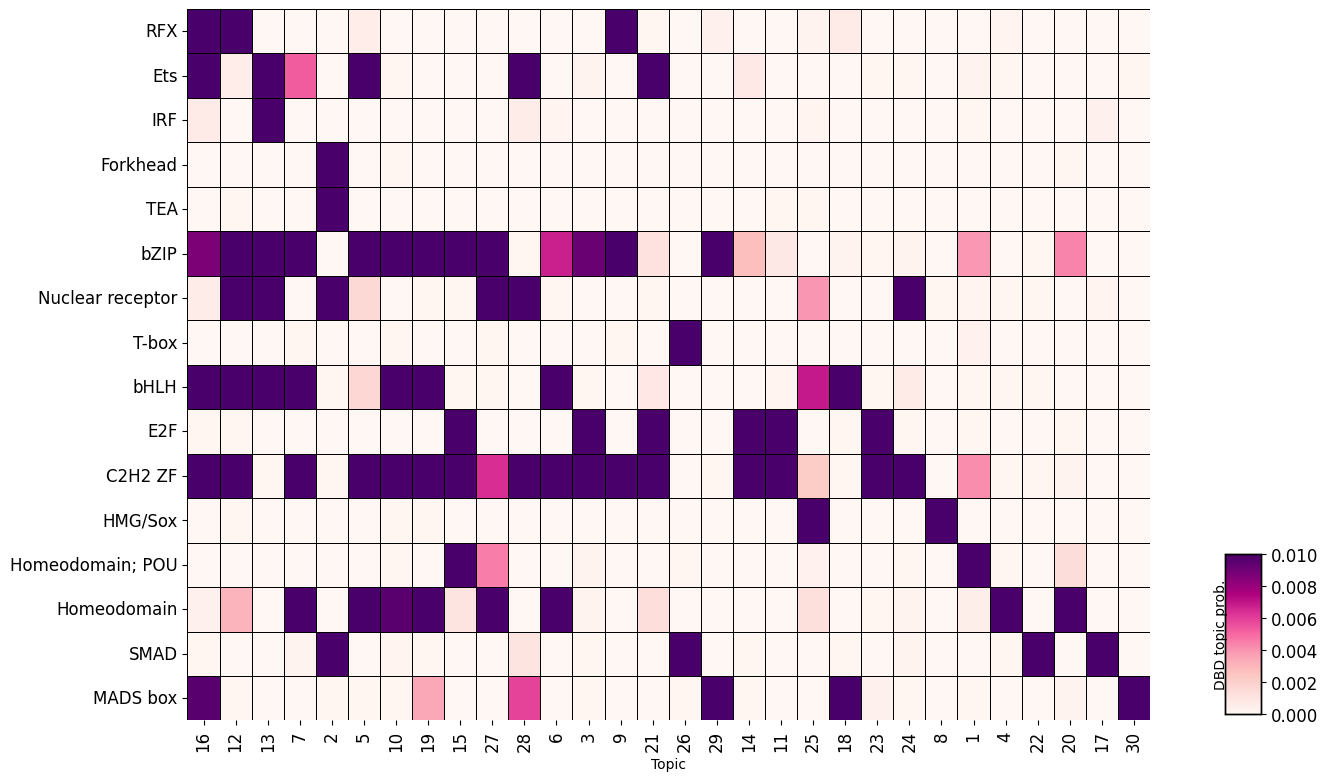

In [12]:
%matplotlib inline
tm.pl.dbd_topic_heatmap(
    adata,
    annotation_col=ANNOTATION_COL,
    width=12,
    height=8,
    x_label_rotation=90,
)

### Topic Visualization in t-SNE Space

Plot t-SNE visualization of regions colored by topic probabilities using {func}`~tfmindi.pl.region_topic_tsne`.

Computing t-SNE coordinates from region-topic matrix...


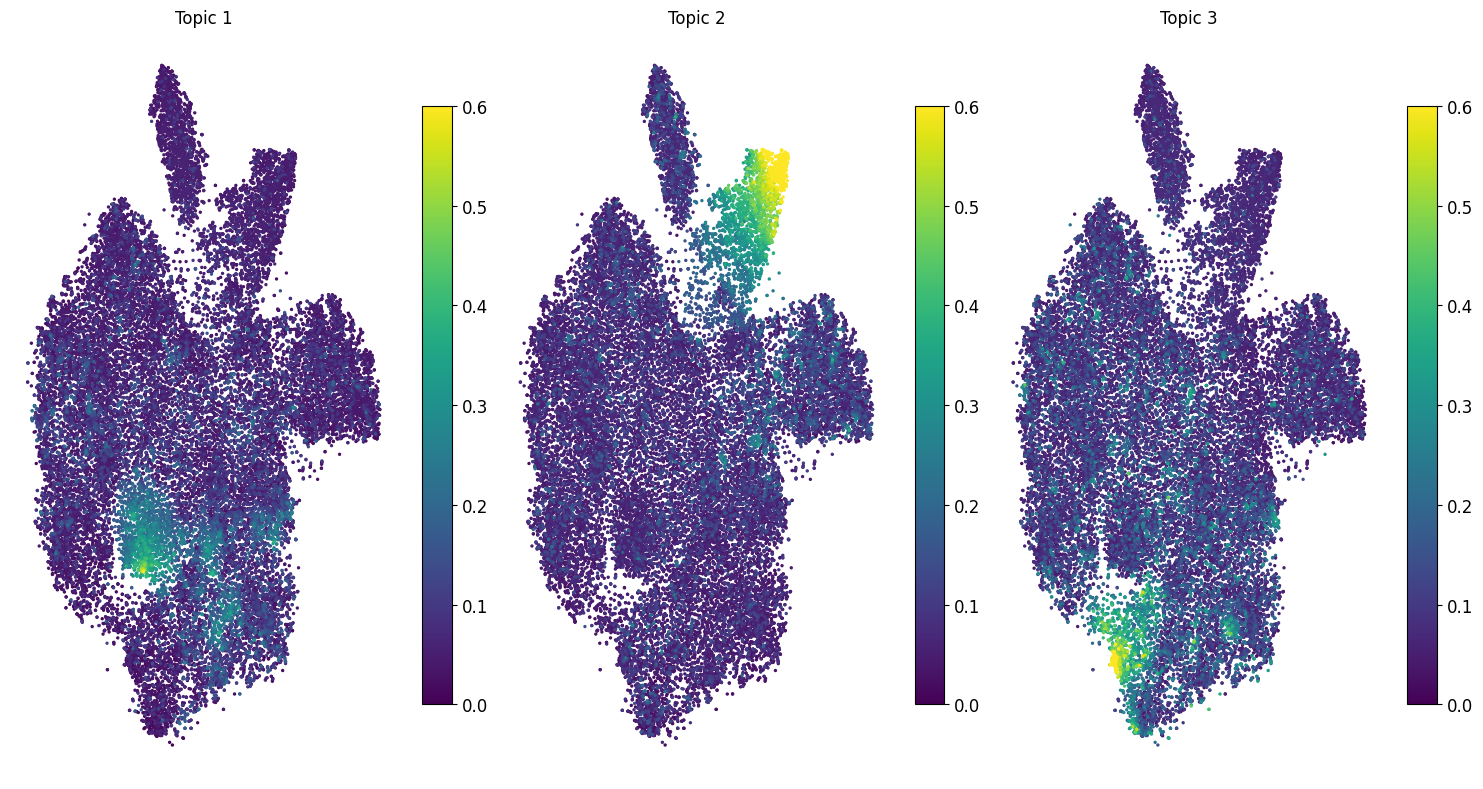

In [13]:
# Plot regions colored by dominant topic
tm.pl.region_topic_tsne(adata, topics_to_show=["Topic_1", "Topic_2", "Topic_3"], ncols=3, width=15)